In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.4 MB/s eta 0:00:00


In [3]:
import torch
import pandas as pd
import PIL
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
import optuna
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

base = '/content/drive/MyDrive/datasets/catdog'

with zipfile.ZipFile(f'{base}/training_set.zip', 'r') as z:
    z.extractall('/content/')

with zipfile.ZipFile(f'{base}/test_set.zip', 'r') as z:
    z.extractall('/content/')

print("Done!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done!


FileNotFoundError: [Errno 2] No such file or directory: '/content/train'

In [8]:

train_transforms = transforms.Compose([
    # 1. Resize & Crop
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    # 2. Flips
    transforms.RandomHorizontalFlip(p=0.5),
    # 3. Color jitter
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    # 4. Rotation
    transforms.RandomRotation(degrees=20),
    # 5. Occasional grayscale
    transforms.RandomGrayscale(p=0.05),
    # 6. Convert + Normalize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ImageNet stats
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),          # no randomness — deterministic
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
test_dataset = ImageFolder("./test_set/test_set", transform=test_transforms)

# 1) Load once without transform to get labels for splitting
full_train = ImageFolder("./training_set/training_set", transform=None)
targets = full_train.targets
indices = np.arange(len(full_train))

# 2) Stratified split so class balance stays similar
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,          # 20% validation
    random_state=42,
    stratify=targets
)

# 3) Create two dataset views with different transforms
train_base = ImageFolder("./training_set/training_set", transform=train_transforms)
val_base   = ImageFolder("./training_set/training_set", transform=test_transforms)  # deterministic

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(val_base, val_idx)




print(len(train_dataset), len(val_dataset), len(test_dataset))

6404 1601 2023


# EDA

In [10]:
from collections import Counter
import numpy as np

class_names = full_train.classes

train_labels = np.array(full_train.targets)[train_idx]
val_labels   = np.array(full_train.targets)[val_idx]
test_labels  = np.array(test_dataset.targets)

def print_class_counts(name, labels):
    counts = Counter(labels)
    print(f"\n{name}:")
    for class_idx, class_name in enumerate(class_names):
        print(f"{class_name}: {counts.get(class_idx, 0)}")

print_class_counts("Train", train_labels)
print_class_counts("Val", val_labels)
print_class_counts("Test", test_labels)


Train:
cats: 3200
dogs: 3204

Val:
cats: 800
dogs: 801

Test:
cats: 1011
dogs: 1012


Width  — min: 224, max: 224, mean: 224
Height — min: 224, max: 224, mean: 224
Channels — unique values: {3}


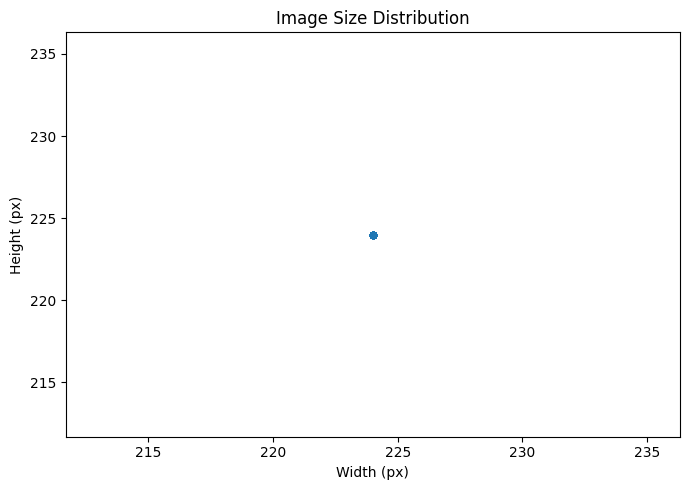

In [11]:
def analyze_image_properties(dataset, sample_size=100):
    widths, heights, channels = [], [], []

    indices = np.random.choice(len(dataset), min(sample_size, len(dataset)), replace=False)

    for idx in indices:
        try:
            img, _ = dataset[idx]  # (image, label)

            # If tensor: C x H x W
            if hasattr(img, "shape"):
                c, h, w = img.shape
            else:
                # If PIL image
                w, h = img.size
                c = len(img.getbands())

            widths.append(w)
            heights.append(h)
            channels.append(c)

        except Exception:
            pass

    print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
    print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
    print(f"Channels — unique values: {set(channels)}")

    # Scatter plot
    plt.figure(figsize=(7, 5))
    plt.scatter(widths, heights, alpha=0.4, s=20)
    plt.xlabel("Width (px)")
    plt.ylabel("Height (px)")
    plt.title("Image Size Distribution")
    plt.tight_layout()
    plt.savefig("eda_sizes.png", dpi=150)
    plt.show()

    if max(widths) / min(widths) > 3 or max(heights) / min(heights) > 3:
        print("⚠️  High size variance — make sure your preprocessing resizes consistently")

analyze_image_properties(train_dataset)

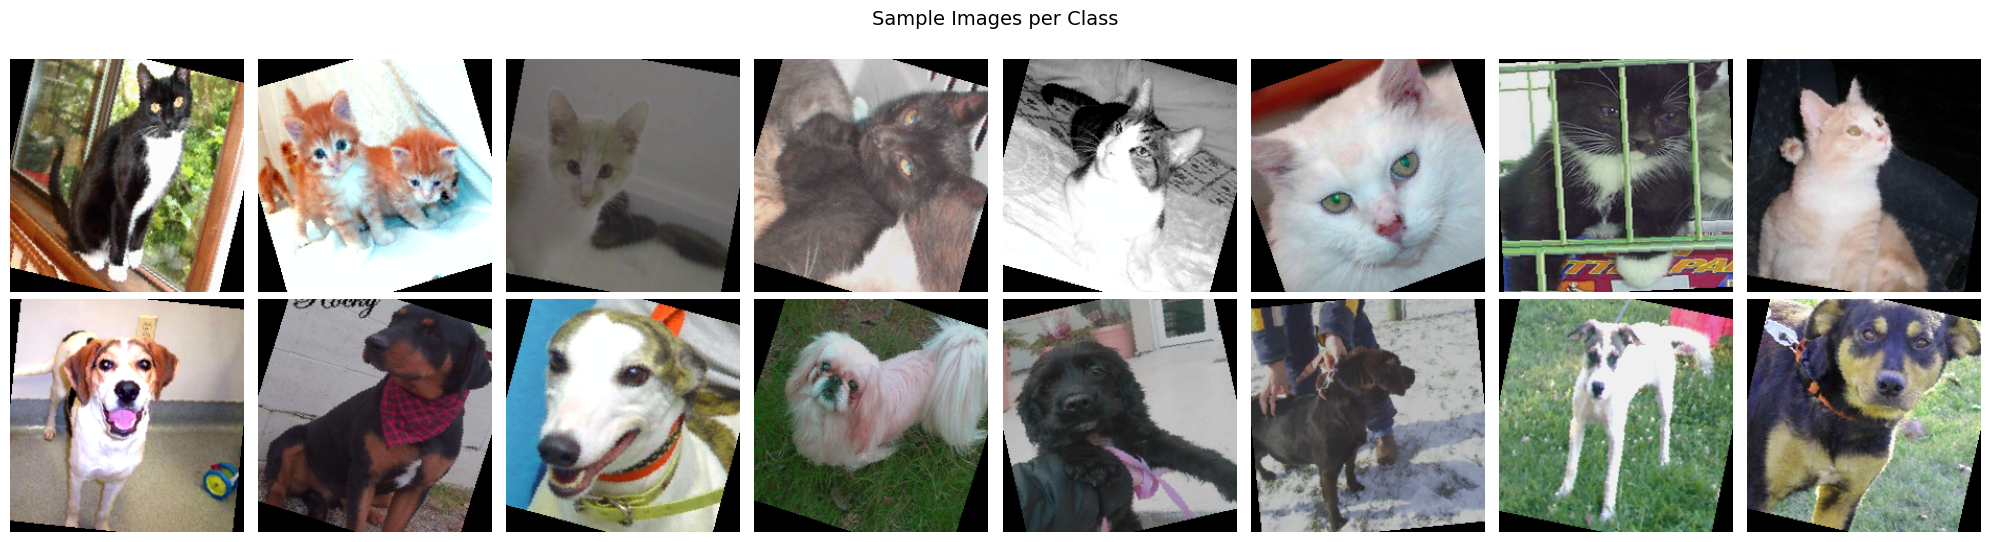

In [12]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Subset


def _extract_targets_and_classes(dataset):
    """Return labels and class names for ImageFolder or Subset(ImageFolder)."""
    if isinstance(dataset, Subset):
        base = dataset.dataset
        subset_indices = np.array(dataset.indices)

        if hasattr(base, "targets"):
            all_targets = np.array(base.targets)
            targets = all_targets[subset_indices].tolist()
        else:
            targets = [base[i][1] for i in subset_indices]

        if hasattr(base, "classes"):
            classes = list(base.classes)
        else:
            unique_labels = sorted(set(targets))
            classes = [f"class_{i}" for i in unique_labels]

        return targets, classes

    if hasattr(dataset, "targets"):
        targets = list(dataset.targets)
    else:
        targets = [dataset[i][1] for i in range(len(dataset))]

    if hasattr(dataset, "classes"):
        classes = list(dataset.classes)
    else:
        unique_labels = sorted(set(targets))
        classes = [f"class_{i}" for i in unique_labels]

    return targets, classes


def show_samples(dataset, n_per_class=8, seed=42):
    rng = np.random.default_rng(seed)
    targets, classes = _extract_targets_and_classes(dataset)

    class_to_indices = defaultdict(list)
    for idx, label in enumerate(targets):
        class_to_indices[int(label)].append(idx)

    class_ids = sorted(class_to_indices.keys())
    n_classes = len(class_ids)

    fig, axes = plt.subplots(
        n_classes,
        n_per_class,
        figsize=(n_per_class * 2.5, n_classes * 2.8),
        squeeze=False,
    )

    imagenet_mean = np.array([0.485, 0.456, 0.406])
    imagenet_std = np.array([0.229, 0.224, 0.225])

    for row, class_id in enumerate(class_ids):
        indices = class_to_indices[class_id]
        k = min(n_per_class, len(indices))
        sampled_positions = rng.choice(indices, size=k, replace=False)

        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis("off")

            if col >= k:
                continue

            sample_pos = int(sampled_positions[col])
            img, _ = dataset[sample_pos]

            if hasattr(img, "permute"):
                img = img.permute(1, 2, 0).cpu().numpy()

                # Undo ImageNet normalization for display.
                if img.ndim == 3 and img.shape[-1] == 3:
                    img = img * imagenet_std + imagenet_mean

                img = np.clip(img, 0, 1)

            ax.imshow(img)

            if col == 0:
                label_name = classes[class_id] if class_id < len(classes) else f"class_{class_id}"
                ax.set_ylabel(label_name, fontsize=11, rotation=0, labelpad=40, va="center")

    plt.suptitle("Sample Images per Class", fontsize=14)
    plt.tight_layout()
    plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
    plt.show()


show_samples(train_dataset, n_per_class=8)

In [13]:
# 4) Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


In [14]:

for batch_features, batch_labels in train_loader:
    print("Batch features shape:", batch_features.shape)
    print("Batch labels shape:", batch_labels.shape)
    break

Batch features shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


# Training

In [15]:
model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 186MB/s]


In [17]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [16]:
def training_loop(model, train_loader, val_loader,optimizer,epochs):

    losses = []
    accuracies = []

    patience = 3
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / total
        accuracy = correct / total
        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                loss = nn.CrossEntropyLoss()(outputs, labels)
                val_loss += loss.item() * features.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / val_total
        val_accuracy = val_correct / val_total
        print(f"Validation - Loss: {avg_val_loss:.4f} - Accuracy: {val_accuracy:.4f}")
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break




In [18]:
for p in model.features.parameters():
    p.requires_grad = False


model.classifier[1] = nn.Linear(in_features=1280, out_features=2)

In [19]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [20]:
training_loop(model.to(device), train_loader, val_loader, optim.Adam(model.parameters(), lr=1e-3), epochs=20)

Epoch 1/20 - Loss: 0.1971 - Accuracy: 0.9293
Validation - Loss: 0.1085 - Accuracy: 0.9681
Epoch 2/20 - Loss: 0.1232 - Accuracy: 0.9528
Validation - Loss: 0.0876 - Accuracy: 0.9713
Epoch 3/20 - Loss: 0.1111 - Accuracy: 0.9597
Validation - Loss: 0.0773 - Accuracy: 0.9731
Epoch 4/20 - Loss: 0.1132 - Accuracy: 0.9505
Validation - Loss: 0.0761 - Accuracy: 0.9731
Epoch 5/20 - Loss: 0.1108 - Accuracy: 0.9567
Validation - Loss: 0.0788 - Accuracy: 0.9681
Epoch 6/20 - Loss: 0.1079 - Accuracy: 0.9589
Validation - Loss: 0.0754 - Accuracy: 0.9719
Epoch 7/20 - Loss: 0.1121 - Accuracy: 0.9535
Validation - Loss: 0.0726 - Accuracy: 0.9700
Epoch 8/20 - Loss: 0.1061 - Accuracy: 0.9571
Validation - Loss: 0.0717 - Accuracy: 0.9744
Epoch 9/20 - Loss: 0.1112 - Accuracy: 0.9553
Validation - Loss: 0.0699 - Accuracy: 0.9744
Epoch 10/20 - Loss: 0.1087 - Accuracy: 0.9594
Validation - Loss: 0.0684 - Accuracy: 0.9744
Epoch 11/20 - Loss: 0.1115 - Accuracy: 0.9538
Validation - Loss: 0.0696 - Accuracy: 0.9750
Epoch 12

In [21]:
for param in model.parameters():
    param.requires_grad = True


In [22]:
training_loop(model.to(device), train_loader, val_loader, optim.Adam(model.classifier.parameters(), lr=1e-4), epochs=20)

Epoch 1/20 - Loss: 0.1086 - Accuracy: 0.9561
Validation - Loss: 0.0630 - Accuracy: 0.9756
Epoch 2/20 - Loss: 0.1070 - Accuracy: 0.9550
Validation - Loss: 0.0694 - Accuracy: 0.9763
Epoch 3/20 - Loss: 0.0914 - Accuracy: 0.9644
Validation - Loss: 0.0646 - Accuracy: 0.9775
Epoch 4/20 - Loss: 0.1010 - Accuracy: 0.9588
Validation - Loss: 0.0654 - Accuracy: 0.9744
Early stopping triggered


In [23]:
# evaluate
model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        test_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
avg_test_loss = test_loss / test_total
test_accuracy = test_correct / test_total
print(f"Test - Loss: {avg_test_loss:.4f} - Accuracy: {test_accuracy:.4f}")

Test - Loss: 0.0597 - Accuracy: 0.9792
